## Comparing SSE and METISSE with COSMIC

Let us rerun the example for COSMIC that we used in [METISSE with COSMIC](../cosmic.md) page, but now let us compare the output when the same binary is evolved using COSMIC and SSE.

This page is based on a Jupyter notebook created by Tom Wagg. Used with permission.

:::{Note}

* This tutorial was generated from a Jupyter notebook using NBSphinx. The notebook is available [here](https://github.com/TeamMETISSE/METISSE/tree/develop/docs/source/notebook/metisse_cosmic_example.ipynb).
* If you choose to run this notebook, make sure the paths in the notebook for the track libraries are correct.

:::

Import Python Packages

In [1]:
# import cosmic
from cosmic.evolve import Evolve
from cosmic.sample.initialbinarytable import InitialBinaryTable
import matplotlib.pyplot as plt
import numpy as np
import astropy.constants as consts
import astropy.units as u

fs = 24

In [2]:
# matplotlibrc file for prettier plots 
# Courtesy: Earl Bellinger 
plt.style.use('matplotlibrc')

In [3]:
kstar_translator = [
    {'long': 'Main Sequence (Low mass)', 'short': 'MS < 0.7', 'colour': (0.996078, 0.843476, 0.469158, 1.0)},
    {'long': 'Main Sequence', 'short': 'MS', 'colour': (0.996078, 0.843476, 0.469158, 1.0)},
    {'long': 'Hertzsprung Gap', 'short': 'HG', 'colour': (0.939608, 0.471373, 0.094902, 1.0)},
    {'long': 'First Giant Branch', 'short': 'FGB', 'colour': (0.716186, 0.833203, 0.916155, 1.0)},
    {'long': 'Core Helium Burning', 'short': 'CHeB', 'colour': (0.29098, 0.59451, 0.78902, 1.0)},
    {'long': 'Early AGB', 'short': 'EAGB', 'colour': (0.294902, 0.690196, 0.384314, 1.0)},
    {'long': 'Thermally Pulsing AGB', 'short': 'TPAGB',
     'colour': (0.723122, 0.889612, 0.697178, 1.0)},
    {'long': 'Helium Main Sequence', 'short': 'HeMS', 'colour': (0.254627, 0.013882, 0.615419, 1.0)},
    {'long': 'Helium Hertsprung Gap', 'short': 'HeHG', 'colour': (0.562738, 0.051545, 0.641509, 1.0)},
    {'long': 'Helium Giant Branch', 'short': 'HeGB', 'colour': (0.798216, 0.280197, 0.469538, 1.0)},
    {'long': 'Helium White Dwarf', 'short': 'HeWD', 'colour': (0.368166, 0.232828, 0.148275, 1.0)},
    {'long': 'Carbon/Oxygen White Dwarf', 'short': 'COWD', 'colour': (0.620069, 0.392132, 0.249725, 1.0)},
    {'long': 'Oxygen/Neon White Dwarf', 'short': 'ONeWD', 'colour': (0.867128, 0.548372, 0.349225, 1.0)},
    {'long': 'Neutron Star', 'short': 'NS', 'colour': (0.501961, 0.501961, 0.501961, 1.0)},
    {'long': 'Black Hole', 'short': 'BH', 'colour': (0.0, 0.0, 0.0, 1.0)},
    {'long': 'Massless Remnant', 'short': 'MR', 'colour': (1.0, 1.0, 0.0, 1.0)},
    {'long': 'Chemically Homogeneous', 'short': 'CHE', 'colour': (0.647059, 0.164706, 0.164706, 1.0)}
]

Set up input

In [4]:
SSEDict = {
    'stellar_engine': 'metisse', 
    'path_to_tracks': '/Users/poojan/stellar_tracks/MESA/METISSE_INPUT_FILES/Hydrogen/', 
    'path_to_he_tracks': '/Users/poojan/stellar_tracks/MESA/METISSE_INPUT_FILES/Helium/' 
}

In [5]:
BSEDict = {'xi': 1.0, 'bhflag': 1, 'neta': 0.5, 'windflag': 3, 'wdflag': 1, 'alpha1': [1.0,1.0], 'pts1': 0.001, 'pts3': 0.02, 'pts2': 0.01, 'epsnov': 0.001, 'hewind': 0.5, 'ck': 1000, 'bwind': 0.0, 'lambdaf': 0.0, 'mxns': 3.0, 'beta': -1.0, 'tflag': 1, 'acc2': 1.5, 'grflag' : 1, 'remnantflag': 4, 'ceflag': 0, 'eddfac': 1.0, 'ifflag': 0, 'bconst': 3000, 'sigma': 265.0, 'gamma': -2.0, 'pisn': 45.0, 'natal_kick_array' : [[-100.0,-100.0,-100.0,-100.0,0.0], [-100.0,-100.0,-100.0,-100.0,0.0]], 'bhsigmafrac' : 1.0, 'polar_kick_angle' : 90, 'qcrit_array' : [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0], 'cekickflag' : 2, 'cehestarflag' : 0, 'cemergeflag' : 0, 'ecsn' : 2.25, 'ecsn_mlow' : 1.6, 'aic' : 1, 'ussn' : 0, 'sigmadiv' :-20.0, 'qcflag' : 1, 'eddlimflag' : 0, 'fprimc_array' : [2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0], 'bhspinflag' : 0, 'bhspinmag' : 0.0, 'rejuv_fac' : 1.0, 'rejuvflag' : 0, 'htpmb' : 1, 'ST_cr' : 1, 'ST_tide' : 1, 'bdecayfac' : 1, 'rembar_massloss' : 0.5, 'kickflag' : 1, 'zsun' : 0.014, 'bhms_coll_flag' : 0, 'don_lim' : -1, 'acc_lim' : [-1,-1], 'rtmsflag' : 0, 'wd_mass_lim': 1}

In [6]:
single_binary = InitialBinaryTable.InitialBinaries(m1=85, m2=75, porb=500,
                                                ecc=0.4, tphysf=13700.0,
                                                kstar1=1, kstar2=1, metallicity=0.02)

Run COSMIC, first using METISSE as the stellar engine and then using SSE. 

In [7]:
bcms = {
    'metisse': Evolve.evolve(
        initialbinarytable=single_binary,
        BSEDict=BSEDict, 
        SSEDict=SSEDict,
        dtp=0.0
    )[1],
    'sse': Evolve.evolve(
        initialbinarytable=single_binary,
        BSEDict=BSEDict, 
        SSEDict={'stellar_engine': 'sse',},
        dtp=0.0
    )[1]
}

### Comparing the Outputs:

When the binary is evolved using **COSMIC with METISSE**, it forms a **binary black hole system**.
However, when evolved using **COSMIC with SSE**, the stars merge, leaving behind a **single black hole**. 

In [8]:
for k in bcms:
    print(f'--- {k.upper()} ---')
    print(f'Primary \t= {bcms[k].iloc[-1]["mass_1"]:1.2f} Msun ({kstar_translator[bcms[k].iloc[-1]["kstar_1"]]["short"]})')
    print(f'Secondary \t= {bcms[k].iloc[-1]["mass_2"]:1.2f} Msun ({kstar_translator[bcms[k].iloc[-1]["kstar_2"]]["short"]})')
    print(f'Separation \t= {bcms[k].iloc[-1]["sep"]:1.2f} Rsun')
    print()

--- METISSE ---
Primary 	= 12.47 Msun (BH)
Secondary 	= 18.66 Msun (BH)
Separation 	= 7460.18 Rsun

--- SSE ---
Primary 	= 4.43 Msun (BH)
Secondary 	= 8.18 Msun (BH)
Separation 	= -1.00 Rsun



### Hertzsprung–Russell Diagram


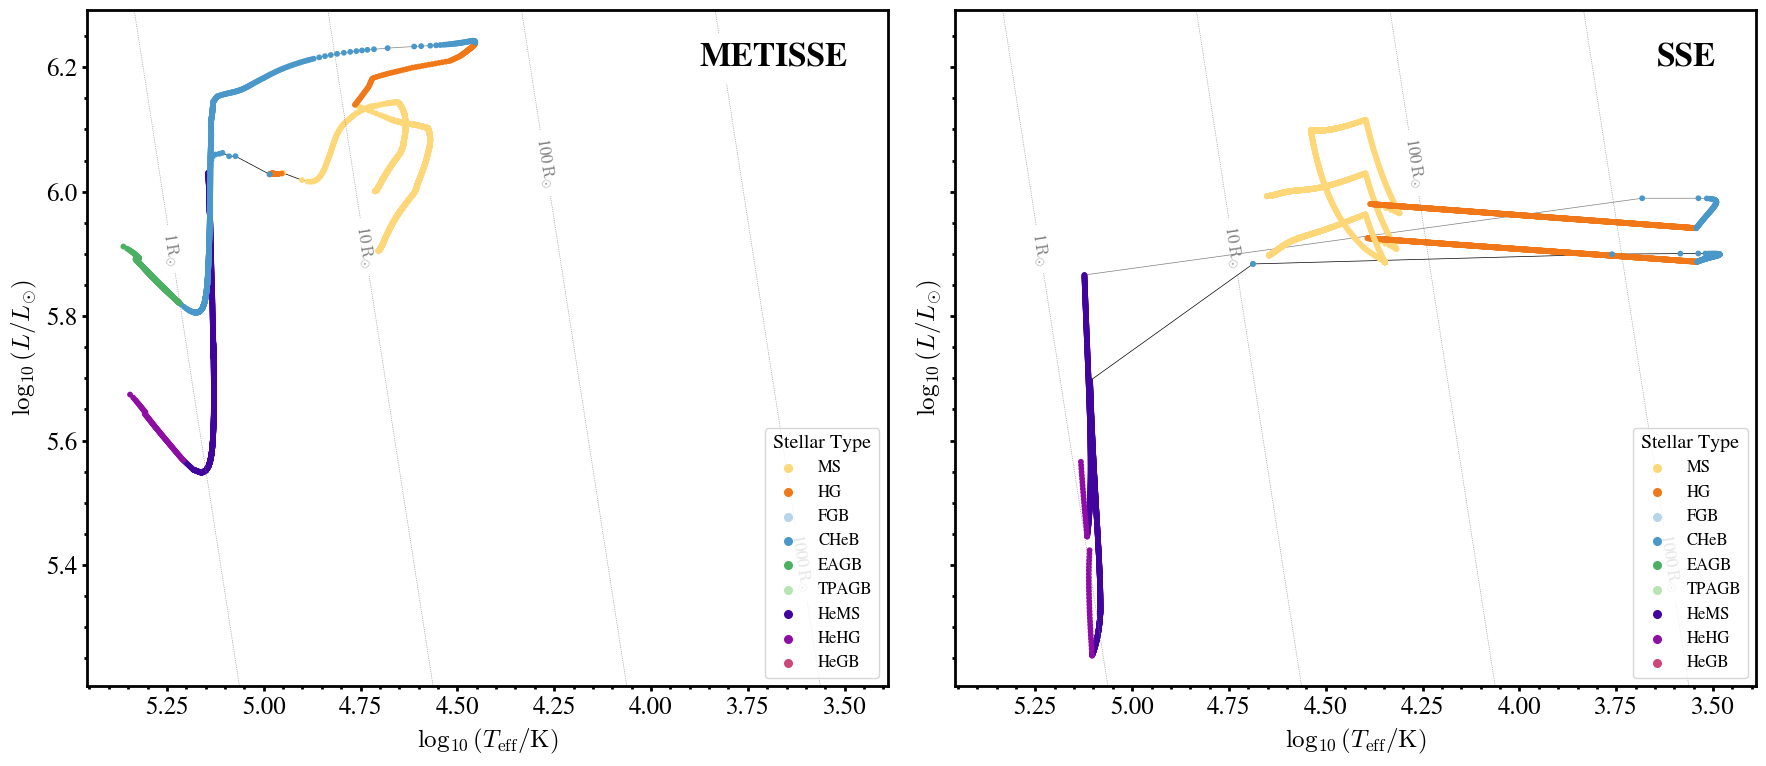

In [9]:
def get_R_from_L_T(L, T):
    return np.sqrt(L / (4 * np.pi * consts.sigma_sb * T**4)).to(u.Rsun)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True, layout='tight')

s = 10

# loop over different engines and create an HRD
for bcm, ax in zip(bcms.values(), axes):

    # plot the primary star
    mask = bcm["kstar_1"] < 13
    ax.scatter(np.log10(bcm["teff_1"][mask]), np.log10(bcm["lum_1"][mask]), c=[kstar_translator[k]["colour"] for k in bcm["kstar_1"][mask]], s=s)
    ax.plot(np.log10(bcm["teff_1"][mask]), np.log10(bcm["lum_1"][mask]), lw=0.5, color='black', zorder=-1)

    # plot the secondary star
    mask = bcm["kstar_2"] < 13
    ax.scatter(np.log10(bcm["teff_2"][mask]), np.log10(bcm["lum_2"][mask]), c=[kstar_translator[k]["colour"] for k in bcm["kstar_2"][mask]], s=s)
    ax.plot(np.log10(bcm["teff_2"][mask]), np.log10(bcm["lum_2"][mask]), lw=0.5, color='grey', zorder=-1)


ax.invert_xaxis()

for ax, label in zip(axes, ['METISSE', 'SSE']):
    ax.set(
        xlabel=r'$\log_{10}(T_{\mathrm{eff}}/\mathrm{K})$',
        ylabel=r'$\log_{10}(L/L_{\odot})$',
    )

    # add lines of constant radius using a grid of Teff and L, with the get_R_from_L_T function
    

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # create a range of temperatures and luminosities (and use Astropy units)
    T_eff = np.logspace(xlim[0], xlim[1], 1000) * u.K
    Lum = np.logspace(ylim[0], ylim[1], 1000) * u.Lsun
    
    # turn these into a grid
    L, T = np.meshgrid(Lum, T_eff)
    
    # compute the radius for this grid and convert to solar radii
    R = get_R_from_L_T(L, T)
    
    # make a contour plot of these values
    cont = ax.contour(np.log10(T.value), np.log10(L.value), np.log10(R.to(u.Rsun).value),
                        levels=[-3, -2, -1, 0, 1, 2, 3], colors="grey", zorder=1, linewidths=0.5, linestyles="dotted")
    
    # format the labels nicely with solar radii
    def fmt(x):
        if x < 0:
            return "{}".format(10**(x)) + r"$\,{\rm R_{\odot}}$"
        else:
            return "{}".format(int(np.round(10**(x)))) + r"$\,{\rm R_{\odot}}$"

    # label the lines
    ax.clabel(cont, fmt=fmt, use_clabeltext=True, rightside_up=True, fontsize=0.5*fs)

    ax.annotate(label, xy=(0.95, 0.95), xycoords='axes fraction', fontsize=fs, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', lw=0),
                weight='bold')
    
    for kstar in range(1,10):
        ax.scatter([], [], c=[kstar_translator[kstar]["colour"]], label=kstar_translator[kstar]["short"], s=30)
    ax.legend(title='Stellar Type', fontsize=0.5*fs, title_fontsize=0.6*fs, loc='lower right')


Clearly, binaries show different evolutionary patterns with METISSE compared to SSE. To investigate this further, let's compare how the mass and radius of the stars changes over time.

### Mass vs Time

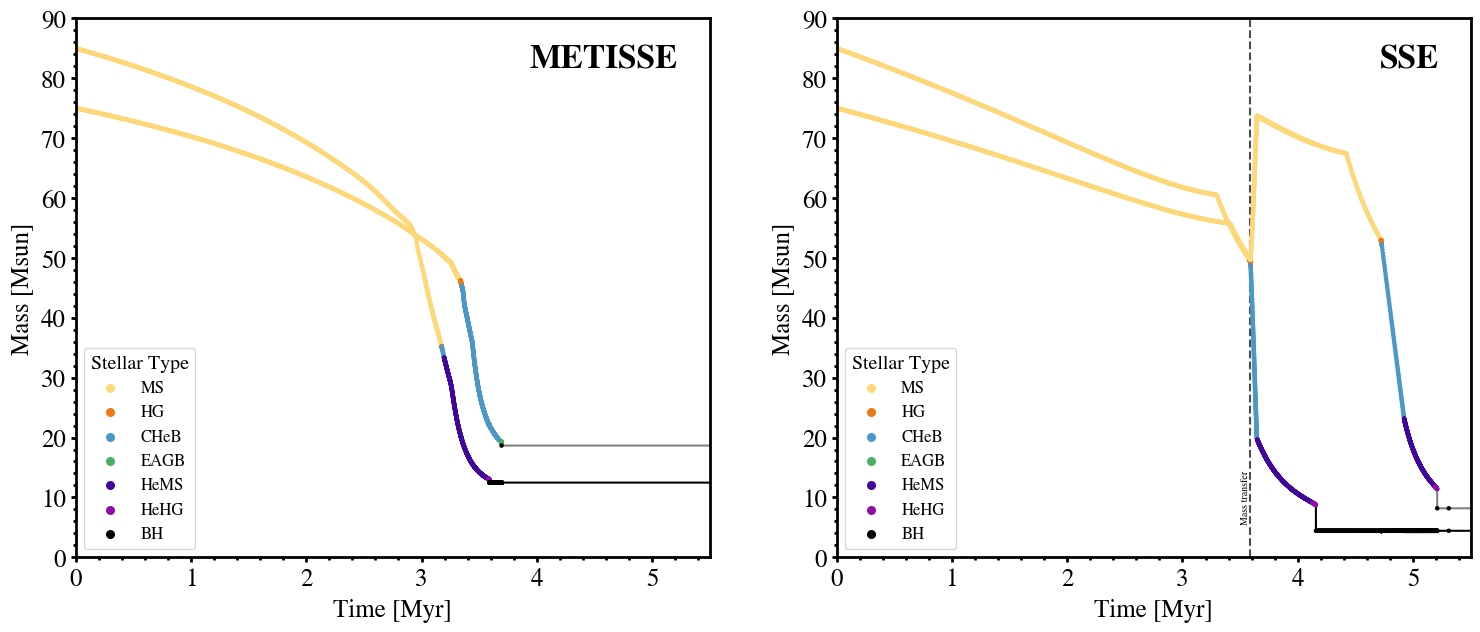

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

s = 5

# loop over different engines 
for bcm, ax in zip(bcms.values(), axes):

    # plot the primary star
    ax.scatter(bcm["tphys"], bcm["mass_1"], c=[kstar_translator[k]["colour"] for k in bcm["kstar_1"]], s=s)
    ax.plot(bcm["tphys"], bcm["mass_1"], lw=1.5, color='black', zorder=-1)

    # plot the secondary star
    ax.scatter(bcm["tphys"], bcm["mass_2"], c=[kstar_translator[k]["colour"] for k in bcm["kstar_2"]], s=s)
    ax.plot(bcm["tphys"], bcm["mass_2"], lw=1.5, color='grey', zorder=-1)

    # Identify rows where mass transfer occurs (RRLO_1 > 1)
    mt_rows = bcm[bcm["RRLO_1"] > 1]
    if len(mt_rows) > 0:
        ax.axvline(mt_rows["tphys"].min(), color='black', ls='--', lw=1.5, alpha=0.7, zorder=-2)
        ax.annotate("Mass transfer", xy=(mt_rows["tphys"].min(), 10), xycoords='data', rotation=90,
                    ha='right', va='center', fontsize=0.3 * fs)



for ax, label in zip(axes, bcms.keys()):
    ax.set(
        xlabel='Time [Myr]',
        ylabel='Mass [Msun]',
        xlim=(0, 5.5),
        ylim=(0, 90)
    )

    ax.annotate(label.upper(), xy=(0.95, 0.95), xycoords='axes fraction', fontsize=fs, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', lw=0),
                weight='bold')
    
    for kstar in [1, 2, 4, 5, 7, 8, 14]:
        ax.scatter([], [], c=[kstar_translator[kstar]["colour"]], label=kstar_translator[kstar]["short"], s=30)
    ax.legend(title='Stellar Type', fontsize=0.5*fs, title_fontsize=0.6*fs, loc='lower left')


### Radius vs Time

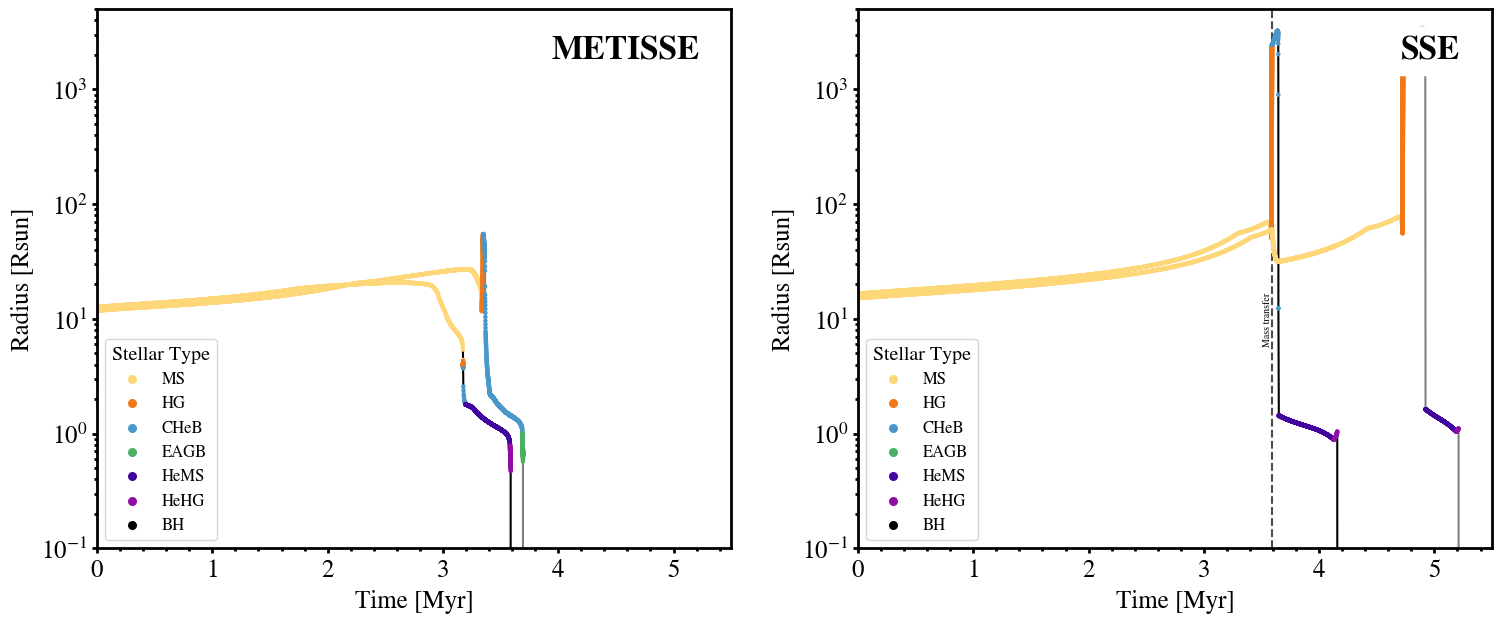

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

s = 5

for bcm, ax in zip(bcms.values(), axes):

    # plot the primary star
    ax.scatter(bcm["tphys"], bcm["rad_1"], c=[kstar_translator[k]["colour"] for k in bcm["kstar_1"]], s=s)
    ax.plot(bcm["tphys"], bcm["rad_1"], lw=1.5, color='black', zorder=-1)

    # plot the secondary star
    ax.scatter(bcm["tphys"], bcm["rad_2"], c=[kstar_translator[k]["colour"] for k in bcm["kstar_2"]], s=s)
    ax.plot(bcm["tphys"], bcm["rad_2"], lw=1.5, color='grey', zorder=-1)

    # Identify rows where mass transfer occurs (RRLO_1 > 1)
    mt_rows = bcm[bcm["RRLO_1"] > 1]
    if len(mt_rows) > 0:
        ax.axvline(mt_rows["tphys"].min(), color='black', ls='--', lw=1.5, alpha=0.7, zorder=-2)
        ax.annotate("Mass transfer", xy=(mt_rows["tphys"].min(), 10), xycoords='data', rotation=90,
                    ha='right', va='center', fontsize=0.3 * fs)


for ax, label in zip(axes, bcms.keys()):
    ax.set(
        xlabel='Time [Myr]',
        ylabel='Radius [Rsun]',
        xlim=(0, 5.5),
        ylim=(1e-1, 5e3),
        yscale="log",
    )

    ax.annotate(label.upper(), xy=(0.95, 0.95), xycoords='axes fraction', fontsize=fs, ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', lw=0),
                weight='bold')
    
    for kstar in [1, 2, 4, 5, 7, 8, 14]:
        ax.scatter([], [], c=[kstar_translator[kstar]["colour"]], label=kstar_translator[kstar]["short"], s=30)
    ax.legend(title='Stellar Type', fontsize=0.5*fs, title_fontsize=0.6*fs, loc='lower left')



SSE and METISSE predict different radial evolutions of the star. This is the reason why the evolution of the binary is so different. This is also shown by the following plot: 

### Radial separation over time

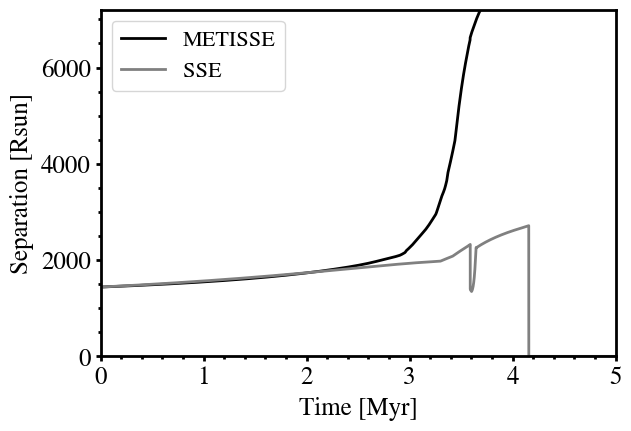

In [12]:
fig, ax = plt.subplots()

for key, bcm in bcms.items():
    ax.plot(bcm["tphys"], bcm["sep"], lw=2, zorder=-1, label=key.upper(), color="grey" if key == "sse" else "black")

ax.set(
    xlabel='Time [Myr]',
    ylabel='Separation [Rsun]',
    xlim=(0, 5),
    ylim=(0, 7200)
)
ax.legend()